In [72]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [73]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [75]:
download(
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv"
)

In [76]:
penguins = pd.read_csv("penguins_raw.csv").dropna(subset=["Body Mass (g)"])
penguins.shape

(342, 17)

In [77]:
adelie = penguins.query('Species.str.startswith("Adelie")')
len(adelie)

151

In [78]:
xvar = "Flipper Length (mm)"
yvar = "Body Mass (g)"

flipper_length = adelie[xvar]
body_mass = adelie[yvar]

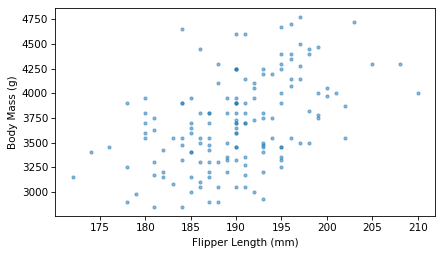

In [79]:
plt.scatter(flipper_length, body_mass, marker=".", alpha=0.5)
decorate(xlabel=xvar, ylabel=yvar)

In [80]:
np.corrcoef(flipper_length, body_mass)[0, 1]

np.float64(0.4682016942179394)

In [81]:
from scipy.stats import linregress

result = linregress(flipper_length, body_mass)
result

LinregressResult(slope=np.float64(32.83168975115009), intercept=np.float64(-2535.8368022002514), rvalue=np.float64(0.46820169421793933), pvalue=np.float64(1.3432645947790051e-09), stderr=np.float64(5.076138407990821), intercept_stderr=np.float64(964.7984274994059))

In [82]:
x = flipper_length.mean()
y = result.intercept + result.slope * x
x, y

(np.float64(189.95364238410596), np.float64(3700.662251655629))

In [83]:
def predict(result, xs):
    ys = result.intercept + result.slope * xs
    return ys

In [84]:
fit_xs = np.linspace(np.min(flipper_length), np.max(flipper_length))
fit_ys = predict(result, fit_xs)

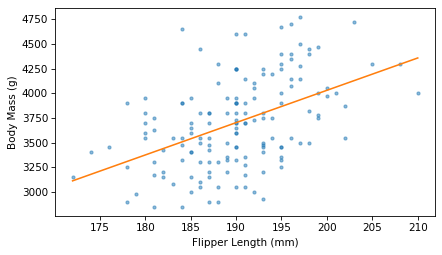

In [85]:
plt.scatter(flipper_length, body_mass, marker=".", alpha=0.5)
plt.plot(fit_xs, fit_ys, color="C1")
decorate(xlabel=xvar, ylabel=yvar)

In [86]:
def compute_residuals(result, xs, ys):
    fit_ys = predict(result, xs)
    return ys - fit_ys

In [87]:
residuals = compute_residuals(result, flipper_length, body_mass)

In [88]:
x = flipper_length[0]
y = predict(result, x)
x, y

(np.float64(181.0), np.float64(3406.699042757914))

In [89]:
body_mass[0], residuals[0]

(np.float64(3750.0), np.float64(343.30095724208604))

In [90]:
mse = np.mean(residuals**2)
mse

np.float64(163098.85902884745)

In [91]:
deviations = body_mass - np.mean(body_mass)

In [92]:
np.mean(deviations**2)

np.float64(208890.28989956583)

In [93]:
np.var(body_mass)

208890.28989956572

In [94]:
def coefficient_of_determination(ys, residuals):
    return 1 - np.var(residuals) / np.var(ys)

In [95]:
R2 = coefficient_of_determination(body_mass, residuals)
R2

0.21921282646854823

In [96]:
r = np.sqrt(R2)
r

np.float64(0.4682016942179388)

In [97]:
corr = np.corrcoef(flipper_length, body_mass)[0, 1]
corr

np.float64(0.4682016942179394)

In [98]:
result.rvalue

np.float64(0.46820169421793933)

In [99]:
intercept = result.intercept + np.random.normal(0, 1)
slope = result.slope + np.random.normal(0, 1)

In [100]:
from types import SimpleNamespace

fake_result = SimpleNamespace(intercept=intercept, slope=slope)
fake_result

namespace(intercept=np.float64(-2535.9991575020863),
          slope=np.float64(32.68395508589116))

In [101]:
fake_residuals = compute_residuals(fake_result, flipper_length, body_mass)
fake_mse = np.mean(fake_residuals**2)

In [102]:
mse, fake_mse, fake_mse > mse

(np.float64(163098.85902884745), np.float64(163896.4420847203), np.True_)

In [103]:
def least_squares(xs, ys):
    xbar = np.mean(xs)
    ybar = np.mean(ys)

    xdev = xs - xbar
    ydev = ys - ybar

    slope = np.sum(xdev * ydev) / np.sum(xdev**2)
    intercept = ybar - slope * xbar

    return intercept, slope

In [104]:
intercept, slope = least_squares(flipper_length, body_mass)
intercept, slope

(np.float64(-2535.8368022002524), np.float64(32.831689751150094))

In [105]:
np.allclose([intercept, slope], [result.intercept, result.slope])

True

In [106]:
def resample(df):
    n = len(df)
    return df.sample(n, replace=True)

In [107]:
def estimate_slope(df):
    xs, ys = df["Flipper Length (mm)"], df["Body Mass (g)"]
    result = linregress(xs, ys)
    return result.slope

In [108]:
# Seed the random number generator so we get the same results every time

np.random.seed(1)

In [109]:
resampled_slopes = [estimate_slope(resample(adelie)) for i in range(1001)]

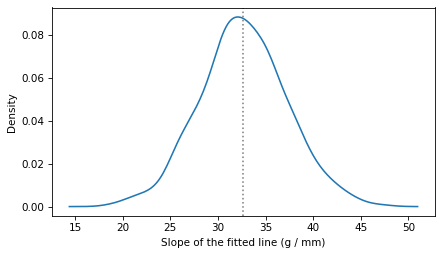

In [110]:
from thinkstats import plot_kde

plot_kde(resampled_slopes)
decorate(xlabel="Slope of the fitted line (g / mm)", ylabel="Density")

In [111]:
ci90 = np.percentile(resampled_slopes, [5, 95])
print(result.slope, ci90)

32.83168975115009 [25.39604591 40.21054526]


In [112]:
stderr = np.std(resampled_slopes)
stderr

np.float64(4.570238986584832)

In [113]:
result.stderr

np.float64(5.076138407990821)

In [114]:
def fit_line(df, fit_xs):
    xs, ys = df["Flipper Length (mm)"], df["Body Mass (g)"]
    result = linregress(xs, ys)
    fit_ys = predict(result, fit_xs)
    return fit_ys

In [115]:
xs = adelie["Flipper Length (mm)"]
fit_xs = np.linspace(np.min(xs), np.max(xs))

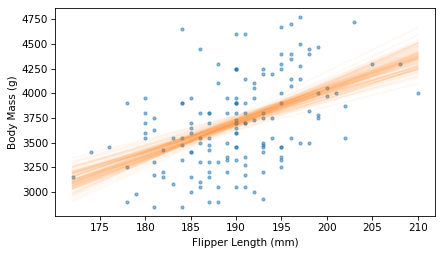

In [116]:
plt.scatter(flipper_length, body_mass, marker=".", alpha=0.5)

for i in range(101):
    fit_ys = fit_line(resample(adelie), fit_xs)
    plt.plot(fit_xs, fit_ys, color="C1", alpha=0.05)

decorate(xlabel=xvar, ylabel=yvar)

In [117]:
fitted_ys = [fit_line(resample(adelie), fit_xs) for i in range(1001)]

In [118]:
low, median, high = np.percentile(fitted_ys, [5, 50, 95], axis=0)

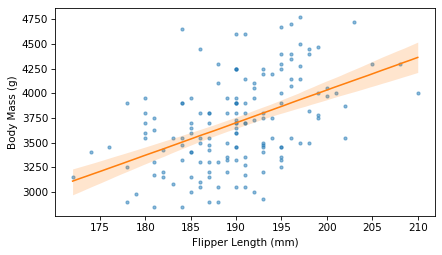

In [119]:
plt.scatter(flipper_length, body_mass, marker=".", alpha=0.5)

plt.fill_between(fit_xs, low, high, color="C1", lw=0, alpha=0.2)
plt.plot(fit_xs, median, color="C1")

decorate(xlabel=xvar, ylabel=yvar)

In [120]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/CDBRFS08.ASC.gz")

In [121]:
from thinkstats import read_brfss

brfss = read_brfss()

In [122]:
valid = brfss.dropna(subset=["htm3", "wtkg2"])
heights, weights = valid["htm3"], valid["wtkg2"]

In [123]:
result_brfss = linregress(heights, weights)
result_brfss.intercept, result_brfss.slope

(np.float64(-82.65926054409877), np.float64(0.957074585033226))

In [124]:
fit_xs = np.linspace(heights.min(), heights.max())
fit_ys = predict(result_brfss, fit_xs)

In [125]:
from thinkstats import jitter

jittered_heights = jitter(heights, 2)
jittered_weights = jitter(weights, 1.5)

In [126]:
m, s = heights.mean(), heights.std()
xlim = m - 4 * s, m + 4 * s
ylim = 0, 200

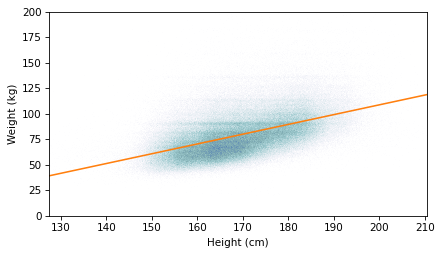

In [127]:
plt.scatter(jittered_heights, jittered_weights, alpha=0.01, s=0.1)
plt.plot(fit_xs, fit_ys, color="C1")
decorate(xlabel="Height (cm)", ylabel="Weight (kg)", xlim=xlim, ylim=ylim)

In [128]:
residuals = compute_residuals(result_brfss, heights, weights)

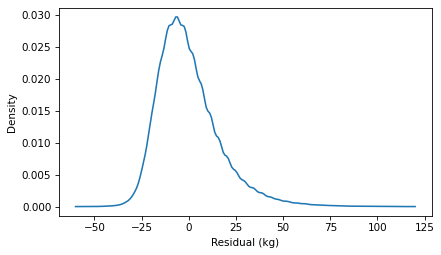

In [129]:
from thinkstats import make_pmf

pmf_kde = make_pmf(residuals, -60, 120)
pmf_kde.plot()

decorate(xlabel="Residual (kg)", ylabel="Density")

In [130]:
log_weights = np.log10(weights)
result_brfss2 = linregress(heights, log_weights)
result_brfss2.intercept, result_brfss2.slope

(np.float64(0.9930804163932876), np.float64(0.005281454169417777))

In [131]:
fit_xs = np.linspace(heights.min(), heights.max())
fit_ys = predict(result_brfss2, fit_xs)

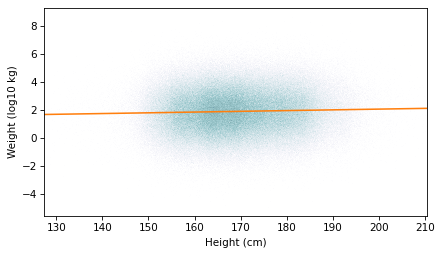

In [132]:
jittered_log_weights = jitter(log_weights, 1.5)
plt.scatter(jittered_heights, jittered_log_weights, alpha=0.01, s=0.1)
plt.plot(fit_xs, fit_ys, color="C1")
decorate(xlabel="Height (cm)", ylabel="Weight (log10 kg)", xlim=xlim)

In [133]:
residuals = compute_residuals(result_brfss2, heights, log_weights)

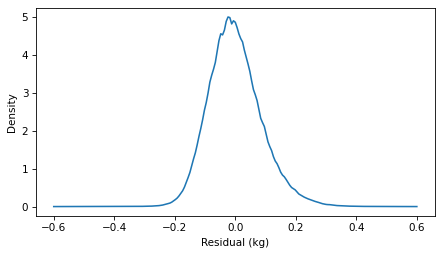

In [134]:
pmf_kde = make_pmf(residuals, -0.6, 0.6)
pmf_kde.plot()

decorate(xlabel="Residual (kg)", ylabel="Density")

In [135]:
result_brfss.rvalue, result_brfss2.rvalue

(np.float64(0.5087364789734582), np.float64(0.5317282605983435))

In [136]:
result_brfss.rvalue**2, result_brfss2.rvalue**2

(np.float64(0.2588128050383119), np.float64(0.28273494311893993))

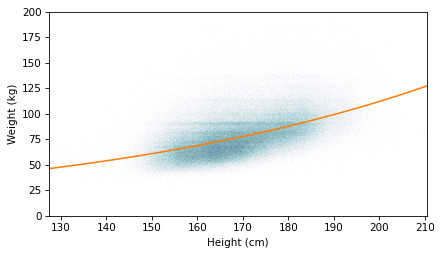

In [137]:
plt.scatter(jittered_heights, jittered_weights, alpha=0.01, s=0.1)
plt.plot(fit_xs, 10**fit_ys, color="C1")
decorate(xlabel="Height (cm)", ylabel="Weight (kg)", xlim=xlim, ylim=ylim)

In [138]:
# Exercise 10.1

xvar = "Culmen Length (mm)"
yvar = "Body Mass (g)"

culmen_length = adelie[xvar]
body_mass = adelie[yvar]

In [139]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [140]:
# Download penguin dataset

!wget -nc https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv

File ‘penguins_raw.csv’ already there; not retrieving.



In [141]:
# Read dataset

penguins = pd.read_csv("penguins_raw.csv")

In [142]:
# Select columns and remove missing values

df = penguins[
    ["Body Mass (g)", "Culmen Length (mm)", "Flipper Length (mm)"]
].dropna()

In [143]:
# Variables

weight = df["Body Mass (g)"]
culmen = df["Culmen Length (mm)"]
flipper = df["Flipper Length (mm)"]

In [144]:
# Least squares fit: weight vs culmen length

result_culmen = linregress(culmen, weight)

print(result_culmen)

LinregressResult(slope=np.float64(87.41527705287557), intercept=np.float64(362.3067216539189), rvalue=np.float64(0.5951098244376304), pvalue=np.float64(3.808282842017693e-34), stderr=np.float64(6.4019853258521575), intercept_stderr=np.float64(283.34523259483007))


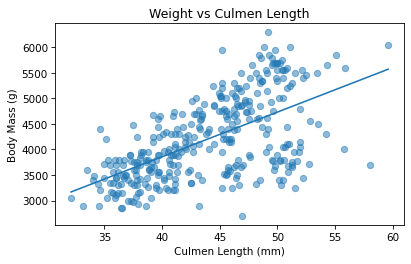

In [145]:
# Scatter plot + fitted line

plt.scatter(culmen, weight, alpha=0.5)

xs = np.linspace(culmen.min(), culmen.max(), 200)

ys = result_culmen.intercept + result_culmen.slope * xs

plt.plot(xs, ys)

plt.xlabel("Culmen Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Weight vs Culmen Length")

plt.show()

In [146]:
# Correlation and coefficient of determination

r = result_culmen.rvalue

r_squared = r**2

print("Correlation =", r)

print("Coefficient of determination =", r_squared)

Correlation = 0.5951098244376304
Coefficient of determination = 0.35415570314218725


In [147]:
# Compare with flipper length

result_flipper = linregress(flipper, weight)

print("Flipper correlation =", result_flipper.rvalue)

print("Flipper R^2 =", result_flipper.rvalue**2)

Flipper correlation = 0.8712017673060114
Flipper R^2 = 0.7589925193571176


In [148]:
# Exercise 10.2

In [149]:
heights_m = heights / 100
bmis = weights / heights_m**2

In [150]:
# Select Adelie penguins

adelie = penguins[
    penguins["Species"].str.startswith("Adelie")
]

adelie = adelie[
    ["Body Mass (g)", "Flipper Length (mm)"]
].dropna()

In [151]:
# Function to estimate intercept

def estimate_intercept(resampled):

    x = resampled["Flipper Length (mm)"]

    y = resampled["Body Mass (g)"]

    result = linregress(x, y)

    return result.intercept

In [152]:
# Resampling

intercepts = []

for i in range(1000):

    sample = adelie.sample(
        len(adelie),
        replace=True
    )

    intercept = estimate_intercept(sample)

    intercepts.append(intercept)

intercepts = np.array(intercepts)

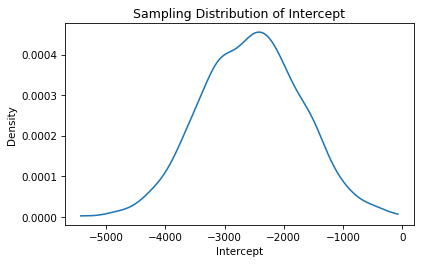

In [153]:
# KDE plot

from scipy.stats import gaussian_kde

kde = gaussian_kde(intercepts)

xs = np.linspace(intercepts.min(), intercepts.max(), 200)

plt.plot(xs, kde(xs))

plt.xlabel("Intercept")
plt.ylabel("Density")
plt.title("Sampling Distribution of Intercept")

plt.show()

In [154]:
# Standard error

stderr = intercepts.std()

print("Standard error =", stderr)

Standard error = 832.051127677634


In [155]:
# 90% confidence interval

low = np.percentile(intercepts, 5)

high = np.percentile(intercepts, 95)

print("90% CI =", (low, high))

90% CI = (np.float64(-3895.4790177459104), np.float64(-1187.0323577981496))


In [156]:
# Compare with regression stderr

x = adelie["Flipper Length (mm)"]

y = adelie["Body Mass (g)"]

result = linregress(x, y)

print("Regression intercept stderr =", result.intercept_stderr)

Regression intercept stderr = 964.7984274994059


In [157]:
# Exercise 10.3

# Example BRFSS-like data

np.random.seed(1)

height = np.random.normal(170, 10, 5000)

weight = 0.025 * height**2 + np.random.normal(0, 8, 5000)

In [158]:
# Remove invalid values

df = pd.DataFrame({
    "height": height,
    "weight": weight
})

df = df[
    (df["height"] > 100) &
    (df["weight"] > 20)
]

In [159]:
# Log transforms

log_height = np.log(df["height"])

log_weight = np.log(df["weight"])

In [160]:
# Least squares fit

result = linregress(log_height, log_weight)

print(result)

LinregressResult(slope=np.float64(2.0023099688781767), intercept=np.float64(-3.700869999244646), rvalue=np.float64(0.9955521870546924), pvalue=np.float64(0.0), stderr=np.float64(0.002680241670918893), intercept_stderr=np.float64(0.01376524965981049))


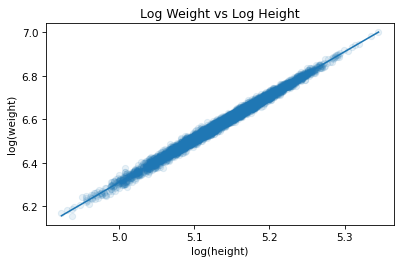

In [161]:
# Plot

plt.scatter(log_height, log_weight, alpha=0.1)

xs = np.linspace(log_height.min(), log_height.max(), 200)

ys = result.intercept + result.slope * xs

plt.plot(xs, ys)

plt.xlabel("log(height)")
plt.ylabel("log(weight)")
plt.title("Log Weight vs Log Height")

plt.show()

In [162]:
# Estimated exponent

print("Estimated exponent =", result.slope)

Estimated exponent = 2.0023099688781767
